In [1]:
from scipy import stats
import pandas as pd
import torch 
import numpy as np
from matplotlib.colors import CenteredNorm,Normalize,TwoSlopeNorm
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import xarray as xr
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from scipy import stats
from get_lat_lon import get_lat_lon
from scipy import stats
import pwlf
import pandas as pd
import numpy as np

In [2]:
# flattern the time, latitude, longitude for each sample
df=pd.read_csv('/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/567_568_569/A-158328-3.csv')

In [55]:
# Load target variable (soil moisture data) and extract the last feature dimension
y = np.load('/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/input/smc_somo.npy')[:, :, -1]

# Identify indices where soil moisture data has NaN values at time step 205
nanindex = np.where(np.isnan(y[:, 205]))

# Load the GAM model results containing LAIA and ED data
df = pd.read_csv('/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/567_568_569/A-158328-3.csv')

# Load selected cell indices
sa_xcell = np.load("/User/homes/fhuang/lac_cnn/sa_x_cell.npy")

# Load previously identified NaN indices and remove those cells
nan_idx = np.load('/Net/Groups/BGI/scratch/fhuang/sm_uta_cnn/conv3d_res/nan_idx.npy')
sa_xcell = np.delete(sa_xcell, nan_idx, axis=0)

# Also remove cells with NaN values in soil moisture data
sa_xcell = np.delete(sa_xcell, nanindex, axis=0)

# Initialize DataFrame to store piecewise linear regression results
piece_res = pd.DataFrame()

# Initialize array to store fitted values (x_hat and y_hat) for all cells
# Dimensions: [cells(733), time_steps(216), variables(2)]
hat = np.full((733, 216, 2), np.nan)

# Loop through each of the 733 cells
for i in range(733):
    try:
        # Get current cell index and its geographic coordinates
        x_cell = sa_xcell[i]
        lat_center, lon_center = get_lat_lon(x_cell)
        
        # Extract data for the current cell from the GAM results
        dfi = df[(df['lat'] == lat_center) & (df['lon'] == lon_center)]
        
        # Extract LAIA (Leaf Area Index Anomaly) and ED (Ecological Drought) variables
        x = dfi['laia']  # Independent variable: Leaf Area Index Anomaly
        y = dfi['ed_new']  # Dependent variable: Ecological Drought index
        
        # Fit piecewise linear regression with 2 segments (1 breakpoint)
        my_pwlf = pwlf.PiecewiseLinFit(x, y)
        breaks = my_pwlf.fit(2)  # Fit model with 2 line segments
        
        # Predict using the fitted model
        x_hat = x
        y_hat = my_pwlf.predict(x_hat)
        
        # Store the fitted values
        hat[i, :, 0] = x_hat  # LAIA values
        hat[i, :, 1] = y_hat  # Predicted ED values
        
        # Extract regression statistics
        beta = my_pwlf.beta  # Regression coefficients
        se = my_pwlf.standard_errors()  # Standard errors of coefficients
        t = beta / se  # t-statistics
        n = len(x)  # Number of observations
        k = len(beta)  # Number of parameters
        pvalues = stats.t.sf(abs(t), df=n-k-1)  # Calculate p-values
        slopes = my_pwlf.calc_slopes()  # Slopes of each segment
        r2 = my_pwlf.r_squared()  # R-squared value
        
        # Store results in DataFrame
        piece_res.loc[i, "pixel_idx"] = i  # Pixel index
        piece_res.loc[i, "lat"] = lat_center  # Latitude
        piece_res.loc[i, "lon"] = lon_center  # Longitude
        piece_res.loc[i, "b0"] = breaks[0]  # First breakpoint
        piece_res.loc[i, "b1"] = breaks[1]  # Second breakpoint  
        piece_res.loc[i, "b2"] = breaks[2]  # Third breakpoint
        piece_res.loc[i, "pv0"] = pvalues[0]  # P-value for first segment
        piece_res.loc[i, "pv1"] = pvalues[1]  # P-value for second segment
        piece_res.loc[i, "pv2"] = pvalues[2]  # P-value for third segment
        piece_res.loc[i, "s1"] = slopes[0]  # Slope of first segment
        piece_res.loc[i, "s2"] = slopes[1]  # Slope of second segment
        piece_res.loc[i, "r2"] = r2  # R-squared value
        
        # Classify the relationship pattern based on slope characteristics
        if (slopes[0] >= 0) & (slopes[1] > slopes[0]):
            # Regime 1: Both positive, second segment steeper
            piece_res.loc[i, "regime_pv"] = "Regime 1"
        elif (slopes[0] >= 0) & (slopes[1] < slopes[0]) & (slopes[1] >= 0):
            # Regime 2: Both positive, second segment flatter
            piece_res.loc[i, "regime_pv"] = "Regime 2"
        elif (slopes[0] >= 0) & (slopes[1] < 0):
            # Regime 3: First positive, second negative (turning point)
            piece_res.loc[i, "regime_pv"] = "Regime 3"
        elif (slopes[0] < 0) & (slopes[1] > 0):
            # Regime 4: First negative, second positive (turning point)
            piece_res.loc[i, "regime_pv"] = "Regime 4"
        else:
            # Other patterns not classified
            piece_res.loc[i, "regime_pv"] = np.nan
            
    except Exception as e:
        # Handle any errors during processing and fill with NaN values
        piece_res.loc[i, "pixel_idx"] = i
        piece_res.loc[i, "lat"] = lat_center
        piece_res.loc[i, "lon"] = lon_center
        piece_res.loc[i, "b0"] = np.nan
        piece_res.loc[i, "b1"] = np.nan
        piece_res.loc[i, "b2"] = np.nan
        piece_res.loc[i, "pv0"] = np.nan
        piece_res.loc[i, "pv1"] = np.nan
        piece_res.loc[i, "pv2"] = np.nan
        piece_res.loc[i, "s1"] = np.nan
        piece_res.loc[i, "s2"] = np.nan
        piece_res.loc[i, "r2"] = np.nan
        piece_res.loc[i, "regime_pv"] = np.nan
        hat[i, :, 0] = np.nan
        hat[i, :, 1] = np.nan
        print("** Error processing cell:", i, "Error:", e)
    
    # Continue to next iteration
    continue

** 5


/tmp/ipykernel_2311995/4285352658.py:30: RuntimeWarning: invalid value encountered in divide
  t = beta / se
/Net/Groups/BGI/scratch/fhuang/.conda/envs/hfng/lib/python3.10/site-packages/pwlf/pwlf.py:1373: RuntimeWarning: invalid value encountered in scalar divide
  rsq = 1.0 - (ssr/sst)
/tmp/ipykernel_2311995/4285352658.py:30: RuntimeWarning: invalid value encountered in divide
  t = beta / se
/Net/Groups/BGI/scratch/fhuang/.conda/envs/hfng/lib/python3.10/site-packages/pwlf/pwlf.py:1373: RuntimeWarning: invalid value encountered in scalar divide
  rsq = 1.0 - (ssr/sst)


** 463


/tmp/ipykernel_2311995/4285352658.py:30: RuntimeWarning: invalid value encountered in divide
  t = beta / se
/Net/Groups/BGI/scratch/fhuang/.conda/envs/hfng/lib/python3.10/site-packages/pwlf/pwlf.py:1373: RuntimeWarning: invalid value encountered in scalar divide
  rsq = 1.0 - (ssr/sst)


** 484


...

** 504
** 505
** 522
** 523
** 538
** 539
** 553
** 554


/tmp/ipykernel_2311995/4285352658.py:30: RuntimeWarning: invalid value encountered in divide
  t = beta / se
/Net/Groups/BGI/scratch/fhuang/.conda/envs/hfng/lib/python3.10/site-packages/pwlf/pwlf.py:1373: RuntimeWarning: invalid value encountered in scalar divide
  rsq = 1.0 - (ssr/sst)
/tmp/ipykernel_2311995/4285352658.py:30: RuntimeWarning: invalid value encountered in divide
  t = beta / se
/Net/Groups/BGI/scratch/fhuang/.conda/envs/hfng/lib/python3.10/site-packages/pwlf/pwlf.py:1373: RuntimeWarning: invalid value encountered in scalar divide
  rsq = 1.0 - (ssr/sst)


** 570


/tmp/ipykernel_2311995/4285352658.py:30: RuntimeWarning: invalid value encountered in divide
  t = beta / se
/Net/Groups/BGI/scratch/fhuang/.conda/envs/hfng/lib/python3.10/site-packages/pwlf/pwlf.py:1373: RuntimeWarning: invalid value encountered in scalar divide
  rsq = 1.0 - (ssr/sst)


** 697
** 704
** 724


In [45]:
piece_res.to_csv('/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/567_568_569/A-change_point_piece_res_laia-2.csv')
np.save('/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/567_568_569/A-change_point_piece_res_laia-2-hat.npy',hat)

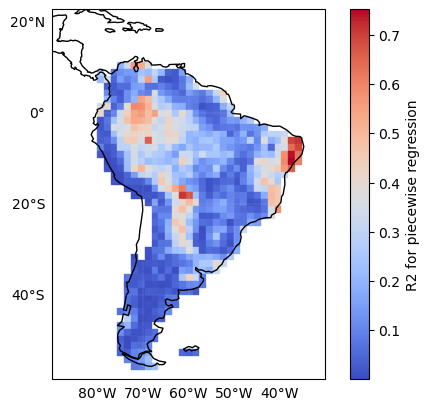

In [95]:
fig, axis = plt.subplots(1, 1, subplot_kw=dict(projection=ccrs.PlateCarree()))
axis.coastlines()  # cartopy function
gl = axis.gridlines(draw_labels=True, linewidth=0.2, color='white', alpha=0.5, linestyle='--')
gl.top_labels=False                                 
gl.right_labels=False
sc=plt.scatter(piece_res.lon,piece_res.lat,s=18,c=piece_res.r2, cmap='coolwarm',marker="s")
plt.colorbar(sc,label="R2 for piecewise regression")

axis.set_extent([-90, -30, -55, 20])

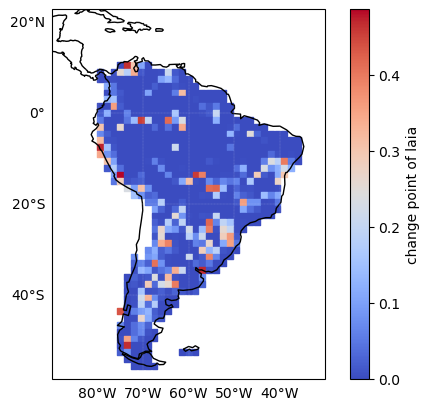

In [96]:
fig, axis = plt.subplots(1, 1, subplot_kw=dict(projection=ccrs.PlateCarree()))
axis.coastlines()  # cartopy function
gl = axis.gridlines(draw_labels=True, linewidth=0.2, color='white', alpha=0.5, linestyle='--')
gl.top_labels=False                                 
gl.right_labels=False
sc=plt.scatter(piece_res.lon,piece_res.lat,s=18,c=piece_res.pv1, cmap='coolwarm',marker="s",)
plt.colorbar(sc,label="change point of laia")

axis.set_extent([-90, -30, -55, 20])